# Chapter 4: The Structure Of Discrete Groups

**Source Span.** Thurston, *Three-Dimensional Geometry and Topology, Volume 1*, Chapter 4, printed pages 209-288. The local source map previously stopped at page 229; this notebook uses the full chapter span through Euclidean and crystallographic groups, elliptic three-manifolds, thick-thin decomposition, Teichmuller space, and fibered geometries.

**Chapter goal.** Make the algebraic restrictions on quotient geometries visible. A manifold modeled on `(G,X)` often has the form `X / Gamma`; this chapter explains why `Gamma` cannot be arbitrary. The notebook turns that into inspectable tests: small generators force nilpotent behavior near the identity, Euclidean crystallographic groups contain a lattice of translations, elliptic examples come from finite group actions on `S^3`, hyperbolic finite-volume manifolds decompose into thick and thin regions, Teichmuller coordinates separate length and twist, and nil/solv fibered geometries are controlled by group extensions.

The prose, figures, computations, and checks are original. They use the textbook only for section coverage and terminology; no textbook prose, exercises, figures, screenshots, or page crops are reproduced.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Polygon, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = 'chapter-04-the-structure-of-discrete-groups'
UNIT_TITLE = 'The Structure Of Discrete Groups'
ART_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ART_ROOT / 'figures'; HTML = ART_ROOT / 'html'; CHECK = ART_ROOT / 'checks'; TABLE = ART_ROOT / 'tables'
ARTIFACTS = []
def remember(path):
    ARTIFACTS.append(Path(path)); return Path(path)
plt.rcParams.update({'figure.figsize': (7.5, 5.2), 'axes.spines.top': False, 'axes.spines.right': False})
display(Markdown(f'Chapter 4 artifacts will be regenerated under `{ART_ROOT.relative_to(BOOK_ROOT).as_posix()}`.'))


Chapter 4 artifacts will be regenerated under `artifacts/chapter-04-the-structure-of-discrete-groups`.

## Visual Storyboard And Library Routing

| Source section | Representation | Library choice | Validation target |
| --- | --- | --- | --- |
| 4.1 Groups generated by small elements | Near-identity generators and commutator shrinkage board | SymPy + Matplotlib | matrix commutators move closer to identity |
| 4.2-4.3 Euclidean/crystallographic manifolds | Lattice and point-group exact sequence diagrams | NetworkX + Matplotlib + Plotly | lattice rank, finite point group, and extension checks |
| 4.4 Elliptic three-manifolds | Spherical quotient family graph | NetworkX | finite subgroups route to lens/binary polyhedral cases |
| 4.5 Thick-thin decomposition | Injectivity-radius threshold plot | Matplotlib + NumPy | thin set is exactly where radius falls below threshold |
| 4.6 Teichmuller space | Fenchel-Nielsen length/twist coordinate lab | Matplotlib + Pandas | dimension count `6g-6` and positive lengths |
| 4.7 Fibered geometries | Nil/Sol extension flowchart | NetworkX + JSON | finite-index extension conditions recorded |

**Library Routing.** Matplotlib gives durable lattice, thick-thin, and Teichmuller diagrams. Plotly is used for a rotatable cubic/body-centered/face-centered lattice comparison. NetworkX represents exact sequences and classification flowcharts. SymPy handles small matrix commutators and dimension formulas exactly. Pandas records the chapter ledgers so final checks can validate the coverage.


In [2]:
routing_rows = [
    {'concept': 'small generators and commutators', 'library': 'SymPy + Matplotlib', 'artifact': 'small-generator-commutator-board.png', 'check': 'commutator closer to identity'},
    {'concept': 'crystallographic exact sequence', 'library': 'NetworkX + Matplotlib', 'artifact': 'crystallographic-exact-sequence.png', 'check': 'lattice-to-point-group path'},
    {'concept': 'three-dimensional lattice families', 'library': 'Plotly', 'artifact': 'crystallographic-lattice-families.html', 'check': 'cubic/BCC/FCC point counts'},
    {'concept': 'thick-thin and Teichmuller coordinates', 'library': 'Matplotlib + Pandas', 'artifact': 'thick-thin-teichmuller-lab.png', 'check': 'threshold and dimension ledger'},
    {'concept': 'nil/solv fibered group extensions', 'library': 'NetworkX', 'artifact': 'fibered-geometries-flowchart.png', 'check': 'flowchart reaches nil and sol outcomes'},
]
routing_path = remember(save_csv(routing_rows, TABLE / 'the-structure-of-discrete-groups-routing.csv'))
display_artifact(routing_path)


[the-structure-of-discrete-groups-routing.csv](D:/Geometry/Three-Dimensional-Geometry-and-Topology/artifacts/chapter-04-the-structure-of-discrete-groups/tables/the-structure-of-discrete-groups-routing.csv)

## 1. Small Generators And Discreteness Near The Identity

The first structural theme is that a discrete subgroup cannot keep producing new elements arbitrarily close to the identity unless it is forced into a controlled nilpotent pattern. The following cell uses two near-identity unipotent matrices. Their commutator is even closer to the identity in a measurable way, which is the finite-matrix shadow of the small-generator arguments.


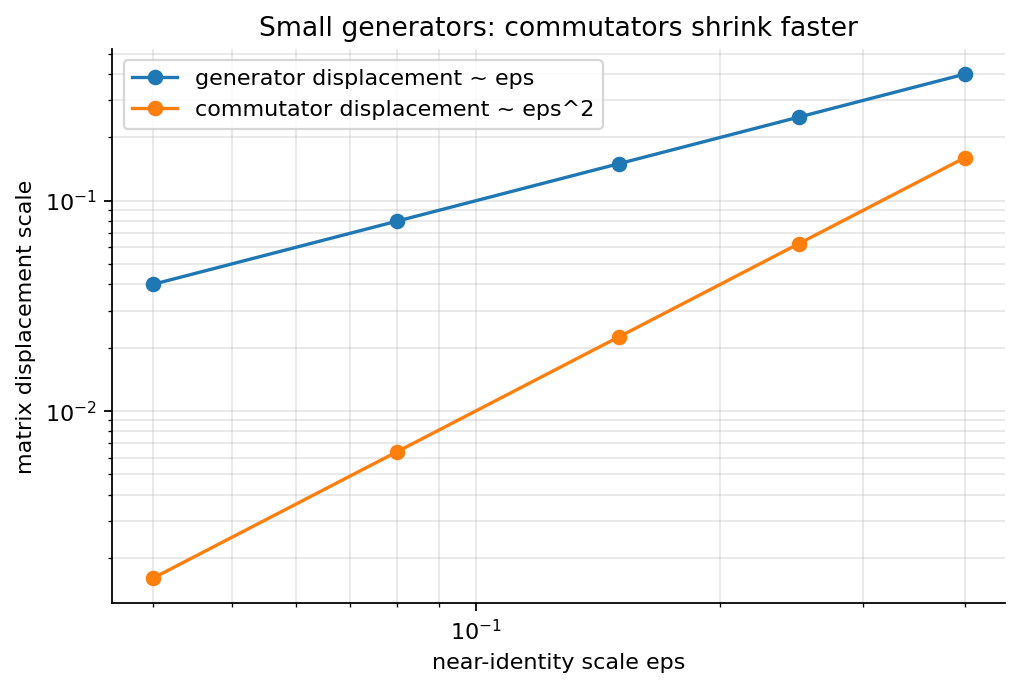

In [3]:
eps = sp.symbols('eps', positive=True)
A = sp.Matrix([[1, eps, 0], [0, 1, 0], [0, 0, 1]])
B = sp.Matrix([[1, 0, 0], [0, 1, eps], [0, 0, 1]])
comm = sp.simplify(A * B * A.inv() * B.inv())
comm_offset = sp.simplify(comm - sp.eye(3))
order_eps = sp.simplify(comm_offset[0,2])
assert order_eps == eps**2

values = np.array([.4, .25, .15, .08, .04])
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.loglog(values, values, marker='o', label='generator displacement ~ eps')
ax.loglog(values, values**2, marker='o', label='commutator displacement ~ eps^2')
ax.set_xlabel('near-identity scale eps'); ax.set_ylabel('matrix displacement scale')
ax.set_title('Small generators: commutators shrink faster')
ax.legend(); ax.grid(alpha=.3, which='both')
small_png = remember(save_matplotlib(fig, FIG / 'small-generator-commutator-board.png'))
plt.close(fig)
small_json = remember(save_json({'commutator': str(comm), 'leading_commutator_term': str(order_eps), 'checks': {'commutator_is_second_order': order_eps == eps**2}}, CHECK / 'small-generator-commutator-board.json'))
display_artifact(small_png)


## 2. Crystallographic Groups: Lattice Plus Finite Point Group

The Euclidean sections reduce a quotient problem to an extension problem. A crystallographic group contains a lattice of translations, and the quotient by that lattice is finite. The graph below records the exact-sequence logic, while the 3D artifact compares three familiar lattice families that appear in the crystallographic discussion.


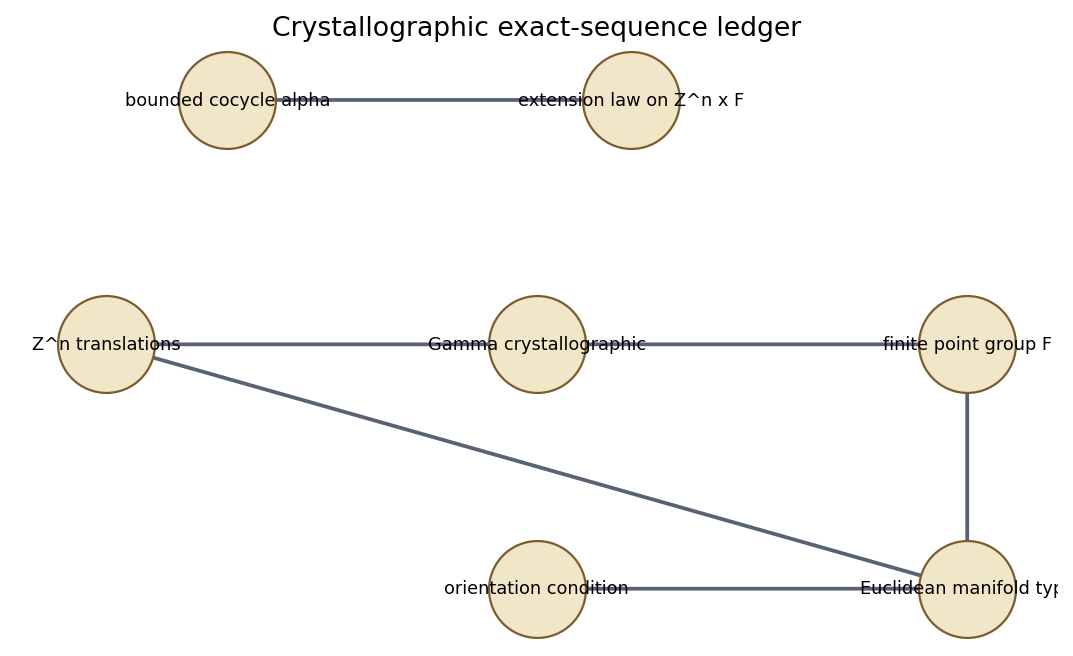

In [4]:
E = nx.DiGraph()
E.add_edges_from([
    ('Z^n translations', 'Gamma crystallographic'),
    ('Gamma crystallographic', 'finite point group F'),
    ('bounded cocycle alpha', 'extension law on Z^n x F'),
    ('finite point group F', 'Euclidean manifold type'),
    ('Z^n translations', 'Euclidean manifold type'),
    ('orientation condition', 'Euclidean manifold type'),
])
pos = {'Z^n translations': (0,0), 'Gamma crystallographic': (1.6,0), 'finite point group F': (3.2,0), 'bounded cocycle alpha': (.45,1.0), 'extension law on Z^n x F': (1.95,1.0), 'orientation condition': (1.6,-1.0), 'Euclidean manifold type': (3.2,-1.0)}
fig, ax = plt.subplots(figsize=(8.4, 4.8))
nx.draw_networkx_edges(E, pos, ax=ax, arrows=True, arrowsize=15, edge_color='#596275', width=1.7)
nx.draw_networkx_nodes(E, pos, ax=ax, node_color='#f1e7c8', edgecolors='#7a5c2e', node_size=1900)
nx.draw_networkx_labels(E, pos, ax=ax, font_size=8)
ax.set_title('Crystallographic exact-sequence ledger')
ax.axis('off')
exact_png = remember(save_matplotlib(fig, FIG / 'crystallographic-exact-sequence.png'))
plt.close(fig)
exact_json = remember(save_json({'nodes': list(E.nodes), 'edges': list(E.edges), 'checks': {'lattice_reaches_manifold_type': nx.has_path(E, 'Z^n translations', 'Euclidean manifold type'), 'point_group_reaches_manifold_type': nx.has_path(E, 'finite point group F', 'Euclidean manifold type')}}, CHECK / 'crystallographic-exact-sequence.json'))
assert nx.has_path(E, 'Z^n translations', 'Euclidean manifold type')
display_artifact(exact_png)


In [5]:
fig = go.Figure()
# cubic lattice
cube_pts = np.array([[i,j,k] for i in [0,1] for j in [0,1] for k in [0,1]], float)
# body-centered and face-centered representative points in one cell
bcc_pts = np.vstack([cube_pts, [[.5,.5,.5]]])
fcc_pts = np.vstack([cube_pts, [[.5,.5,0],[.5,0,.5],[0,.5,.5],[.5,.5,1],[.5,1,.5],[1,.5,.5]]])
for pts, name, color, shift in [(cube_pts, 'cubic', '#2f5d8c', 0), (bcc_pts, 'body-centered', '#b53d3d', 1.6), (fcc_pts, 'face-centered', '#277a4a', 3.2)]:
    fig.add_trace(go.Scatter3d(x=pts[:,0]+shift, y=pts[:,1], z=pts[:,2], mode='markers', marker=dict(size=5, color=color), name=name))
fig.update_layout(title='Cubic, body-centered, and face-centered lattice cells', scene=dict(aspectmode='data'), margin=dict(l=0,r=0,t=40,b=0))
lattice_html = remember(save_plotly_html(fig, HTML / 'crystallographic-lattice-families.html'))
lattice_counts = {'cubic_cell_points': int(len(cube_pts)), 'bcc_cell_points': int(len(bcc_pts)), 'fcc_representative_points': int(len(fcc_pts))}
lattice_json = remember(save_json({'lattice_counts': lattice_counts, 'checks': {'bcc_adds_body_center': lattice_counts['bcc_cell_points'] == lattice_counts['cubic_cell_points'] + 1, 'fcc_has_face_centers': lattice_counts['fcc_representative_points'] > lattice_counts['bcc_cell_points']}}, CHECK / 'crystallographic-lattice-families.json'))
display_artifact(lattice_html, width=820, height=540)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 3. Elliptic Manifolds And Finite Spherical Quotients

Elliptic three-manifolds are quotients of `S^3` by finite groups acting freely. The classification is organized by cyclic/lens-space cases and binary polyhedral families. The graph is intentionally a route map rather than a copied list: it tells the learner which algebraic distinction to inspect.


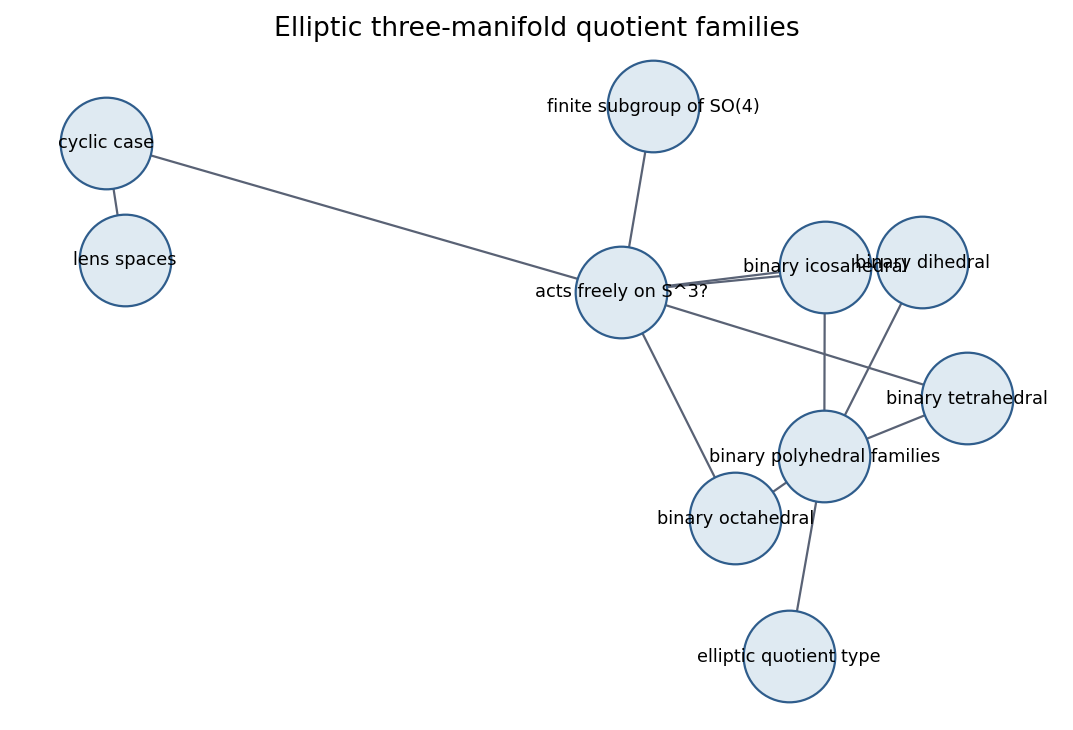

In [6]:
Q = nx.DiGraph()
Q.add_edges_from([
    ('finite subgroup of SO(4)', 'acts freely on S^3?'),
    ('acts freely on S^3?', 'cyclic case'), ('cyclic case', 'lens spaces'),
    ('acts freely on S^3?', 'binary dihedral'), ('acts freely on S^3?', 'binary tetrahedral'),
    ('acts freely on S^3?', 'binary octahedral'), ('acts freely on S^3?', 'binary icosahedral'),
    ('binary polyhedral families', 'elliptic quotient type'),
    ('binary dihedral', 'binary polyhedral families'), ('binary tetrahedral', 'binary polyhedral families'),
    ('binary octahedral', 'binary polyhedral families'), ('binary icosahedral', 'binary polyhedral families'),
])
pos = nx.spring_layout(Q, seed=44)
fig, ax = plt.subplots(figsize=(8.4, 5.4))
nx.draw_networkx_edges(Q, pos, ax=ax, arrows=True, arrowsize=13, edge_color='#596275')
nx.draw_networkx_nodes(Q, pos, ax=ax, node_color='#dfeaf2', edgecolors='#2f5d8c', node_size=1700)
nx.draw_networkx_labels(Q, pos, ax=ax, font_size=8)
ax.set_title('Elliptic three-manifold quotient families')
ax.axis('off')
elliptic_png = remember(save_matplotlib(fig, FIG / 'elliptic-three-manifold-family-map.png'))
plt.close(fig)
elliptic_json = remember(save_json({'family_count': 5, 'checks': {'lens_path_exists': nx.has_path(Q, 'finite subgroup of SO(4)', 'lens spaces'), 'polyhedral_path_exists': nx.has_path(Q, 'finite subgroup of SO(4)', 'elliptic quotient type')}}, CHECK / 'elliptic-three-manifold-family-map.json'))
assert nx.has_path(Q, 'finite subgroup of SO(4)', 'lens spaces')
display_artifact(elliptic_png)


## 4. Thick-Thin Decomposition And Teichmuller Coordinates

The hyperbolic sections introduce a geometric sorting rule: points with small injectivity radius form thin regions, often cusps or tubes, while the complement is thick. Teichmuller space then records hyperbolic surface structures using coordinates such as lengths and twists. The lab below puts both ideas in one figure: a synthetic injectivity-radius profile and a Fenchel-Nielsen coordinate table.


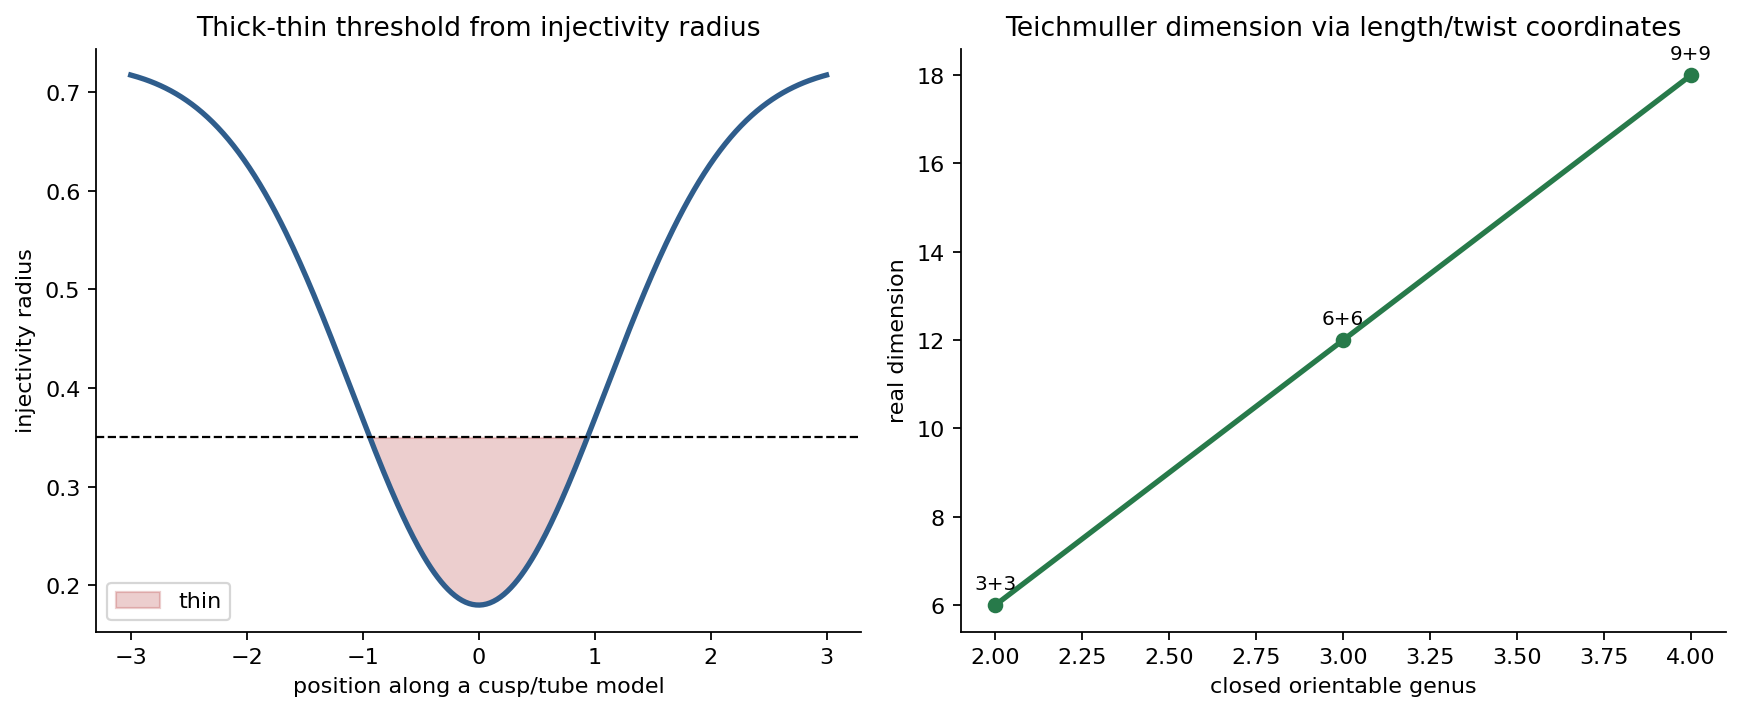

,genus,pants,length_coordinates,twist_coordinates,dimension
0,2,2,3,3,6
1,3,4,6,6,12
2,4,6,9,9,18


In [7]:
x = np.linspace(-3, 3, 400)
inj = 0.18 + 0.55*(1 - np.exp(-0.42*x**2))
threshold = 0.35
thin_mask = inj < threshold
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].plot(x, inj, color='#2f5d8c', lw=2.4)
axes[0].fill_between(x, inj, threshold, where=thin_mask, color='#b53d3d', alpha=.25, label='thin')
axes[0].axhline(threshold, color='black', ls='--', lw=1)
axes[0].set_title('Thick-thin threshold from injectivity radius')
axes[0].set_xlabel('position along a cusp/tube model'); axes[0].set_ylabel('injectivity radius')
axes[0].legend()

teich_rows = []
for genus in [2,3,4]:
    pairs_of_pants = 2*genus - 2
    curves = 3*genus - 3
    teich_rows.append({'genus': genus, 'pants': pairs_of_pants, 'length_coordinates': curves, 'twist_coordinates': curves, 'dimension': 6*genus - 6})
teich_df = pd.DataFrame(teich_rows)
axes[1].plot(teich_df['genus'], teich_df['dimension'], marker='o', color='#277a4a', lw=2.4)
for _, row in teich_df.iterrows():
    axes[1].text(row['genus'], row['dimension']+0.35, f"{int(row['length_coordinates'])}+{int(row['twist_coordinates'])}", ha='center', fontsize=9)
axes[1].set_title('Teichmuller dimension via length/twist coordinates')
axes[1].set_xlabel('closed orientable genus'); axes[1].set_ylabel('real dimension')
fig.tight_layout()
thick_png = remember(save_matplotlib(fig, FIG / 'thick-thin-teichmuller-lab.png'))
plt.close(fig)
teich_csv = remember(save_csv(teich_rows, TABLE / 'teichmuller-coordinate-ledger.csv'))
thick_json = remember(save_json({'thin_fraction': float(thin_mask.mean()), 'threshold': threshold, 'teichmuller_rows': teich_rows, 'checks': {'thin_region_nonempty': bool(thin_mask.any()), 'dimension_formula': all(row['dimension'] == 6*row['genus'] - 6 for row in teich_rows)}}, CHECK / 'thick-thin-teichmuller-lab.json'))
assert thin_mask.any() and all(row['dimension'] == 6*row['genus'] - 6 for row in teich_rows)
display_artifact(thick_png)
teich_df


## 5. Fibered Geometries: Nil And Solv Group Extensions

The final section returns to quotient groups but now for fibered geometries. Nilgeometry and solve-geometry are governed by extensions and finite-index subgroups. The flowchart below is a compact proof scaffold: it records which algebraic facts send the manifold toward nil, solv, or product-like geometry.


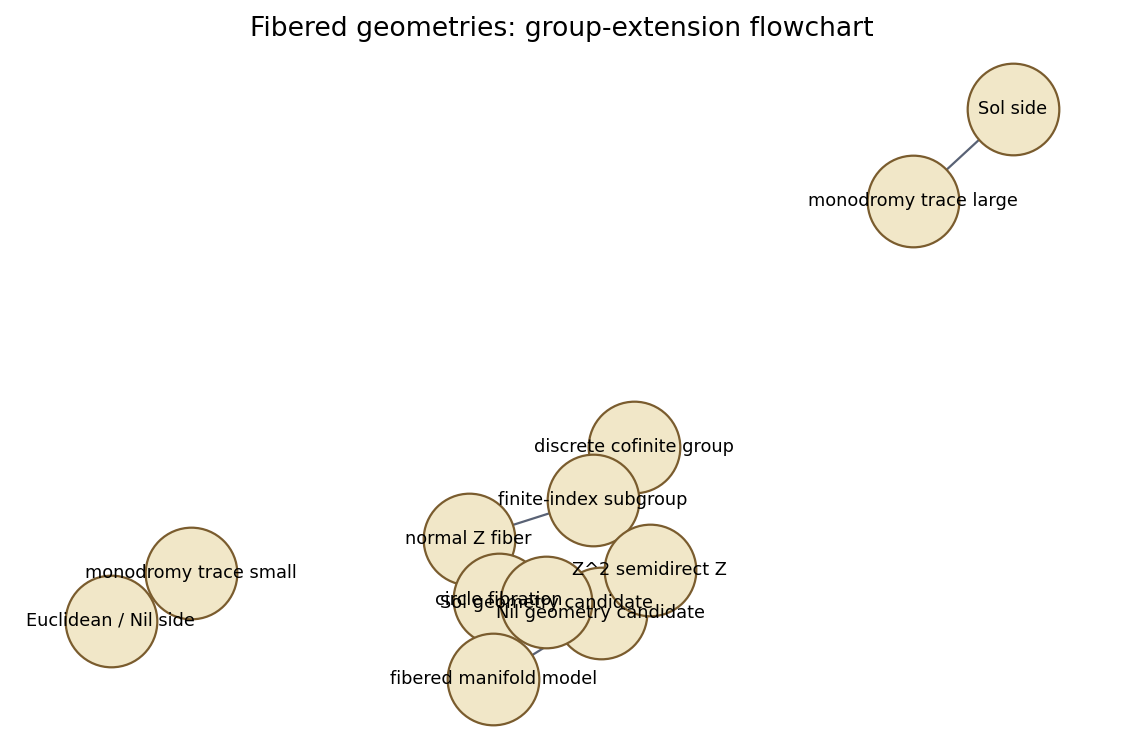

In [8]:
F = nx.DiGraph()
F.add_edges_from([
    ('discrete cofinite group', 'finite-index subgroup'),
    ('finite-index subgroup', 'normal Z fiber'),
    ('normal Z fiber', 'circle fibration'),
    ('circle fibration', 'Nil geometry candidate'),
    ('finite-index subgroup', 'Z^2 semidirect Z'),
    ('Z^2 semidirect Z', 'Sol geometry candidate'),
    ('monodromy trace small', 'Euclidean / Nil side'),
    ('monodromy trace large', 'Sol side'),
    ('Nil geometry candidate', 'fibered manifold model'),
    ('Sol geometry candidate', 'fibered manifold model'),
])
pos = nx.spring_layout(F, seed=11)
fig, ax = plt.subplots(figsize=(8.8, 5.6))
nx.draw_networkx_edges(F, pos, ax=ax, arrows=True, arrowsize=14, edge_color='#596275')
nx.draw_networkx_nodes(F, pos, ax=ax, node_color='#f1e7c8', edgecolors='#7a5c2e', node_size=1700)
nx.draw_networkx_labels(F, pos, ax=ax, font_size=8)
ax.set_title('Fibered geometries: group-extension flowchart')
ax.axis('off')
fiber_png = remember(save_matplotlib(fig, FIG / 'fibered-geometries-flowchart.png'))
plt.close(fig)
fiber_json = remember(save_json({'nodes': list(F.nodes), 'checks': {'nil_path': nx.has_path(F, 'discrete cofinite group', 'Nil geometry candidate'), 'sol_path': nx.has_path(F, 'discrete cofinite group', 'Sol geometry candidate')}}, CHECK / 'fibered-geometries-flowchart.json'))
assert nx.has_path(F, 'discrete cofinite group', 'Nil geometry candidate') and nx.has_path(F, 'discrete cofinite group', 'Sol geometry candidate')
display_artifact(fiber_png)


## Applied Lab: Growth, Lattices, And Monodromy

The applied lab compares two algebraic signals used repeatedly in the chapter. The first is word-ball growth for small generating sets; the second is the trace of a torus-bundle monodromy matrix. A matrix with `|trace| > 2` is hyperbolic on the torus and points toward Sol behavior. This finite computation is a guide to the classification logic, not a classification theorem by itself.


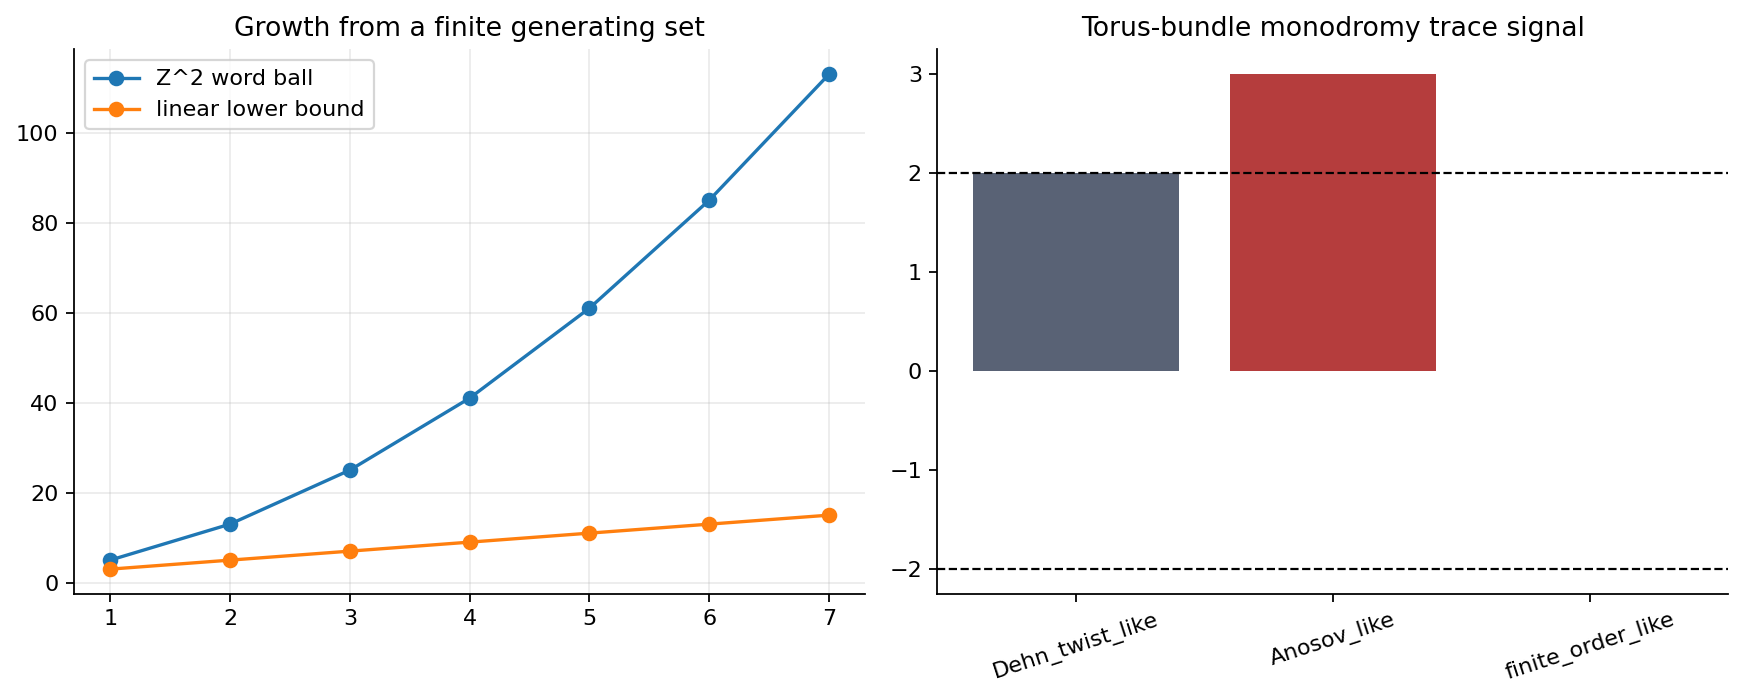

,name,trace,determinant,sol_signal_abs_trace_gt_2
0,Dehn_twist_like,2,1,False
1,Anosov_like,3,1,True
2,finite_order_like,0,1,False


In [9]:
def z2_word_ball(radius):
    return sum(1 for a in range(-radius, radius+1) for b in range(-radius, radius+1) if abs(a)+abs(b) <= radius)
lab_rows = []
for r in range(1, 8):
    lab_rows.append({'radius': r, 'Z2_word_ball': z2_word_ball(r), 'linear_lower_bound': 2*r + 1})
monodromy_mats = {
    'Dehn_twist_like': np.array([[1,1],[0,1]], int),
    'Anosov_like': np.array([[2,1],[1,1]], int),
    'finite_order_like': np.array([[0,-1],[1,0]], int),
}
monodromy_rows = []
for name, M in monodromy_mats.items():
    tr = int(np.trace(M)); det = int(round(np.linalg.det(M)))
    monodromy_rows.append({'name': name, 'trace': tr, 'determinant': det, 'sol_signal_abs_trace_gt_2': abs(tr) > 2})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
lab_df = pd.DataFrame(lab_rows)
axes[0].plot(lab_df['radius'], lab_df['Z2_word_ball'], marker='o', label='Z^2 word ball')
axes[0].plot(lab_df['radius'], lab_df['linear_lower_bound'], marker='o', label='linear lower bound')
axes[0].set_title('Growth from a finite generating set'); axes[0].legend(); axes[0].grid(alpha=.25)
mono_df = pd.DataFrame(monodromy_rows)
axes[1].bar(mono_df['name'], mono_df['trace'], color=['#596275','#b53d3d','#277a4a'])
axes[1].axhline(2, color='black', lw=1, ls='--'); axes[1].axhline(-2, color='black', lw=1, ls='--')
axes[1].set_title('Torus-bundle monodromy trace signal'); axes[1].tick_params(axis='x', rotation=18)
fig.tight_layout()
lab_png = remember(save_matplotlib(fig, FIG / 'applied-lab-growth-monodromy.png'))
plt.close(fig)
lab_csv = remember(save_csv(lab_rows, TABLE / 'applied-lab-growth-ledger.csv'))
mono_csv = remember(save_csv(monodromy_rows, TABLE / 'applied-lab-monodromy-ledger.csv'))
lab_json = remember(save_json({'growth_rows': lab_rows, 'monodromy_rows': monodromy_rows, 'checks': {'growth_exceeds_linear_bound': all(row['Z2_word_ball'] >= row['linear_lower_bound'] for row in lab_rows), 'anosov_like_has_sol_signal': any(row['name'] == 'Anosov_like' and row['sol_signal_abs_trace_gt_2'] for row in monodromy_rows)}}, CHECK / 'growth-monodromy-lab.json'))
assert all(row['Z2_word_ball'] >= row['linear_lower_bound'] for row in lab_rows)
display_artifact(lab_png)
mono_df


## Source-Coverage Note

This chapter now follows the full printed span 209-288, not the truncated 209-229 range that was present in the initial source map. The first cells cover small-generator restrictions and Euclidean crystallographic extensions. The middle cells add elliptic quotient families and the thick-thin decomposition, which are essential for understanding why discrete groups control topology in spherical and hyperbolic settings. The Teichmuller coordinate lab records length and twist dimensions, and the final fibered-geometry flowchart covers the nilgeometry and solve-geometry material near the end of the chapter. The applied growth and monodromy lab then ties those algebraic signals back to quotient geometry.


## Final Sanity Checks

The final cell verifies the revised full source span, artifact existence, nonblank figures, and the central algebraic/geometric checks: commutator shrinkage, crystallographic exact-sequence reachability, finite spherical quotient routing, thick-thin threshold, Teichmuller dimension, fibered-geometry paths, and monodromy signals.


In [10]:
from PIL import Image, ImageStat
chapter_completion_note = 'TDGT Chapter 4 final_sanity: full pages 209-288 discrete groups, crystallography, thick-thin, Teichmuller, fibered geometries.'
assert_artifacts(ARTIFACTS, min_bytes=80)
png_stats = []
for png in sorted(FIG.glob('*.png')):
    with Image.open(png) as img:
        stat = ImageStat.Stat(img.convert('RGB'))
        png_stats.append({'path': png.relative_to(BOOK_ROOT).as_posix(), 'width': img.width, 'height': img.height, 'stddev': max(stat.stddev)})
assert png_stats and all(item['width'] >= 300 and item['height'] >= 250 and item['stddev'] > 1 for item in png_stats)
final_sanity = {
    'unit': UNIT_KEY,
    'source_span': 'printed pages 209-288 (source map repaired from 209-229)',
    'artifact_count': len(ARTIFACTS),
    'png_count_in_artifact_tree': len(png_stats),
    'checks': {
        'commutator_second_order': order_eps == eps**2,
        'crystallographic_exact_sequence_connected': nx.has_path(E, 'Z^n translations', 'Euclidean manifold type'),
        'elliptic_family_paths_present': nx.has_path(Q, 'finite subgroup of SO(4)', 'lens spaces') and nx.has_path(Q, 'finite subgroup of SO(4)', 'elliptic quotient type'),
        'thick_thin_region_nonempty': bool(thin_mask.any()),
        'teichmuller_dimension_formula': all(row['dimension'] == 6*row['genus'] - 6 for row in teich_rows),
        'fibered_geometry_paths_present': nx.has_path(F, 'discrete cofinite group', 'Nil geometry candidate') and nx.has_path(F, 'discrete cofinite group', 'Sol geometry candidate'),
        'applied_lab_growth_and_monodromy': all(row['Z2_word_ball'] >= row['linear_lower_bound'] for row in lab_rows) and any(row['name'] == 'Anosov_like' and row['sol_signal_abs_trace_gt_2'] for row in monodromy_rows),
    },
    'png_stats': png_stats,
}
final_path = remember(save_json(final_sanity, CHECK / 'final-sanity.json'))
assert_artifacts([final_path], min_bytes=300)
display(Markdown(f"final_sanity passed for **{UNIT_TITLE}** with {len(ARTIFACTS)} tracked artifacts."))
final_sanity


final_sanity passed for **The Structure Of Discrete Groups** with 19 tracked artifacts.

{'unit': 'chapter-04-the-structure-of-discrete-groups',
 'source_span': 'printed pages 209-288 (source map repaired from 209-229)',
 'artifact_count': 18,
 'png_count_in_artifact_tree': 6,
 'checks': {'commutator_second_order': True,
  'crystallographic_exact_sequence_connected': True,
  'elliptic_family_paths_present': True,
  'thick_thin_region_nonempty': True,
  'teichmuller_dimension_formula': True,
  'fibered_geometry_paths_present': True,
  'applied_lab_growth_and_monodromy': True},
 'png_stats': [{'path': 'artifacts/chapter-04-the-structure-of-discrete-groups/figures/applied-lab-growth-monodromy.png',
   'width': 1744,
   'height': 700,
   'stddev': 56.95730925984648},
  {'path': 'artifacts/chapter-04-the-structure-of-discrete-groups/figures/crystallographic-exact-sequence.png',
   'width': 1073,
   'height': 656,
   'stddev': 34.24827540783665},
  {'path': 'artifacts/chapter-04-the-structure-of-discrete-groups/figures/elliptic-three-manifold-family-map.png',
   'width': 1073,
 

## Takeaways

- Discrete quotient geometry is constrained by algebra: near-identity generators, finite point groups, and extension data all carry topological consequences.
- Euclidean manifolds are organized by lattices and crystallographic groups; elliptic manifolds by finite free actions on the three-sphere.
- Thick-thin decomposition and Teichmuller coordinates turn hyperbolic geometry into measurable structure.
- Nil and Sol geometries show why fibered three-manifolds are governed by group extensions and monodromy.
- The source map for this course now records the full Chapter 4 span, which is essential for not missing the later sections.
